In [2]:
# ==========================================
# Cell 1: 导入依赖、定义参数与加载数据
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from pathlib import Path

# ---------------- 配置参数 (与 DRL 严格对齐) ----------------
TEST_START_DAY = 0        # 测试起始天数 (n)
TEST_DAYS = 20            # 连续测试的天数
EPISODE_LENGTH = 96       # 每天的步数
N_AGENTS = 3              # 智能体数量

# 物理约束参数
DT = 0.25                 # 时间步长
C_BAT = 1.0               # 电池容量
P_MAX = 0.1               # 最大充放功率
EFF = 1.0                 # 充放电效率
SOC_MIN = 0.05
SOC_MAX = 0.95
INIT_SOC = 0.5

print("=> 初始化参数并加载测试数据...")
data_path = Path.cwd().parent / "data" / "test_prices.csv"
df = pd.read_csv(data_path)

# 提取电价与负荷列
all_prices = df['price'].values
load_cols = [f'load{i+1}' for i in range(N_AGENTS)]
if all([col in df.columns for col in load_cols]):
    all_loads = df[load_cols].values
else:
    # 兼容单列负荷的情况
    all_loads = np.repeat(df['load'].values[:, None], N_AGENTS, axis=1)

print(f"✅ 数据加载成功！总数据长度: {len(all_prices)} 步")

=> 初始化参数并加载测试数据...
✅ 数据加载成功！总数据长度: 15456 步


In [3]:
# ==========================================
# Cell 2: 建立优化模型并执行测试，输出指标
# ==========================================
def solve_daily_oracle(prices, loads):
    """
    针对单日 (96步) 数据，使用 Gurobi 求解具有完美未来信息的全局最优解。
    """
    model = pyo.ConcreteModel()
    model.T = pyo.RangeSet(0, EPISODE_LENGTH - 1)
    model.N = pyo.RangeSet(0, N_AGENTS - 1)

    # 决策变量：充电功率、放电功率、每一步末尾的 SOC
    model.p_chg = pyo.Var(model.N, model.T, domain=pyo.NonNegativeReals, bounds=(0, P_MAX))
    model.p_dis = pyo.Var(model.N, model.T, domain=pyo.NonNegativeReals, bounds=(0, P_MAX))
    model.soc = pyo.Var(model.N, pyo.RangeSet(0, EPISODE_LENGTH), bounds=(SOC_MIN, SOC_MAX))

    # 1. 初始 SOC 约束
    def init_soc_rule(m, n):
        return m.soc[n, 0] == INIT_SOC
    model.init_soc_constr = pyo.Constraint(model.N, rule=init_soc_rule)

    # 2. SOC 状态转移方程
    def soc_dyn_rule(m, n, t):
        # SoC_next = SoC + (P_chg * eff - P_dis / eff) * dt / C_bat
        return m.soc[n, t+1] == m.soc[n, t] + (m.p_chg[n,t] * EFF - m.p_dis[n,t] / EFF) * DT / C_BAT
    model.soc_dyn_constr = pyo.Constraint(model.N, model.T, rule=soc_dyn_rule)

    # 3. 目标函数：最大化纯经济套利收益 (放电赚钱，充电花钱)
    # Profit = \sum_t \sum_n (p_dis - p_chg) * price_t
    def obj_rule(m):
        return sum((m.p_dis[n,t] - m.p_chg[n,t]) * prices[t] for n in m.N for t in m.T)
    model.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

    # 求解器设置
    solver = pyo.SolverFactory('gurobi')
    solver.options['OutputFlag'] = 0 # 关闭求解器的刷屏输出
    res = solver.solve(model)

    # 提取并组装结果
    e_bat_arr = np.zeros((EPISODE_LENGTH, N_AGENTS))
    soc_next_arr = np.zeros((EPISODE_LENGTH, N_AGENTS))
    for t in range(EPISODE_LENGTH):
        for n in range(N_AGENTS):
            # 统一为 e_bat 形式：充电为正，放电为负
            e_bat_arr[t, n] = model.p_chg[n,t]() - model.p_dis[n,t]()
            soc_next_arr[t, n] = model.soc[n, t+1]()
            
    return e_bat_arr, soc_next_arr

# ---------------- 执行循环 ----------------
mpc_results = []
metrics_list = []

print(f"=> 开始执行 Gurobi (Oracle) 测试: 第 {TEST_START_DAY} 天 至 第 {TEST_START_DAY + TEST_DAYS - 1} 天")

for day_idx in range(TEST_START_DAY, TEST_START_DAY + TEST_DAYS):
    start_idx = day_idx * EPISODE_LENGTH
    end_idx = start_idx + EPISODE_LENGTH
    
    daily_prices = all_prices[start_idx:end_idx]
    daily_loads = all_loads[start_idx:end_idx, :]
    
    # 调用 Gurobi 求解
    e_bat_res, soc_res = solve_daily_oracle(daily_prices, daily_loads)
    
    # 组装与 DRL 完全一致的数据字典
    day_data = {
        'price': daily_prices.tolist(), 
        'orig_load': [], 'net_load': [],
        'e_bat': {i: e_bat_res[:, i].tolist() for i in range(N_AGENTS)},
        'soc': {i: [INIT_SOC] + soc_res[:, i].tolist() for i in range(N_AGENTS)}, 
        'daily_profit': 0.0
    }
    
    orig_load_total = np.sum(daily_loads, axis=1)
    net_load_total = orig_load_total + np.sum(e_bat_res, axis=1)
    day_data['orig_load'] = orig_load_total.tolist()
    day_data['net_load'] = net_load_total.tolist()
    
    # 计算每日套利利润
    step_profits = np.sum(-e_bat_res * daily_prices[:, None], axis=1)
    day_data['daily_profit'] = float(np.sum(step_profits))
    
    mpc_results.append(day_data)
    
    # 计算峰谷差指标
    orig_pv_diff = np.max(orig_load_total) - np.min(orig_load_total)
    net_pv_diff = np.max(net_load_total) - np.min(net_load_total)
    pv_improvement = orig_pv_diff - net_pv_diff
    
    metrics_list.append({
        'Day': day_idx,
        'Daily Profit (€/¥)': round(day_data['daily_profit'], 2),
        'Original P-V Diff (kW)': round(orig_pv_diff, 2),
        'Net P-V Diff (kW)': round(net_pv_diff, 2),
        'P-V Improvement (kW)': round(pv_improvement, 2)
    })

# ---------------- 汇总成表格 ----------------
df_metrics = pd.DataFrame(metrics_list)
df_metrics.set_index('Day', inplace=True)

total_profit = df_metrics['Daily Profit (€/¥)'].sum()
avg_daily_profit = df_metrics['Daily Profit (€/¥)'].mean()
avg_pv_improvement = df_metrics['P-V Improvement (kW)'].mean()

print("\n" + "="*50)
print(f"📊 MPC (Gurobi Oracle) 连续 {TEST_DAYS} 天测试指标汇总")
print("="*50)
print(f"💰 理论极限总收益 (Total Profit Oracle): {total_profit:.2f}")
print(f"💸 理论极限日均收益 (Avg Daily Profit): {avg_daily_profit:.2f}")
print(f"📉 平均每日峰谷差改善 (Avg P-V Improvement): {avg_pv_improvement:.2f}")
print("="*50 + "\n")

display(df_metrics)

=> 开始执行 Gurobi (Oracle) 测试: 第 0 天 至 第 19 天

📊 MPC (Gurobi Oracle) 连续 20 天测试指标汇总
💰 理论极限总收益 (Total Profit Oracle): 7230.46
💸 理论极限日均收益 (Avg Daily Profit): 361.52
📉 平均每日峰谷差改善 (Avg P-V Improvement): -0.46



,Daily Profit (€/¥),Original P-V Diff (kW),Net P-V Diff (kW),P-V Improvement (kW)
Day,,,,
0,317.67,0.84,1.43,-0.59
1,281.56,1.01,1.61,-0.60
2,271.33,0.90,1.50,-0.60
3,358.58,0.79,1.39,-0.60
4,419.13,0.84,1.37,-0.53
5,299.69,1.16,1.44,-0.28
6,273.82,0.84,1.40,-0.56
7,556.67,1.12,1.72,-0.60
8,485.66,0.85,1.45,-0.60


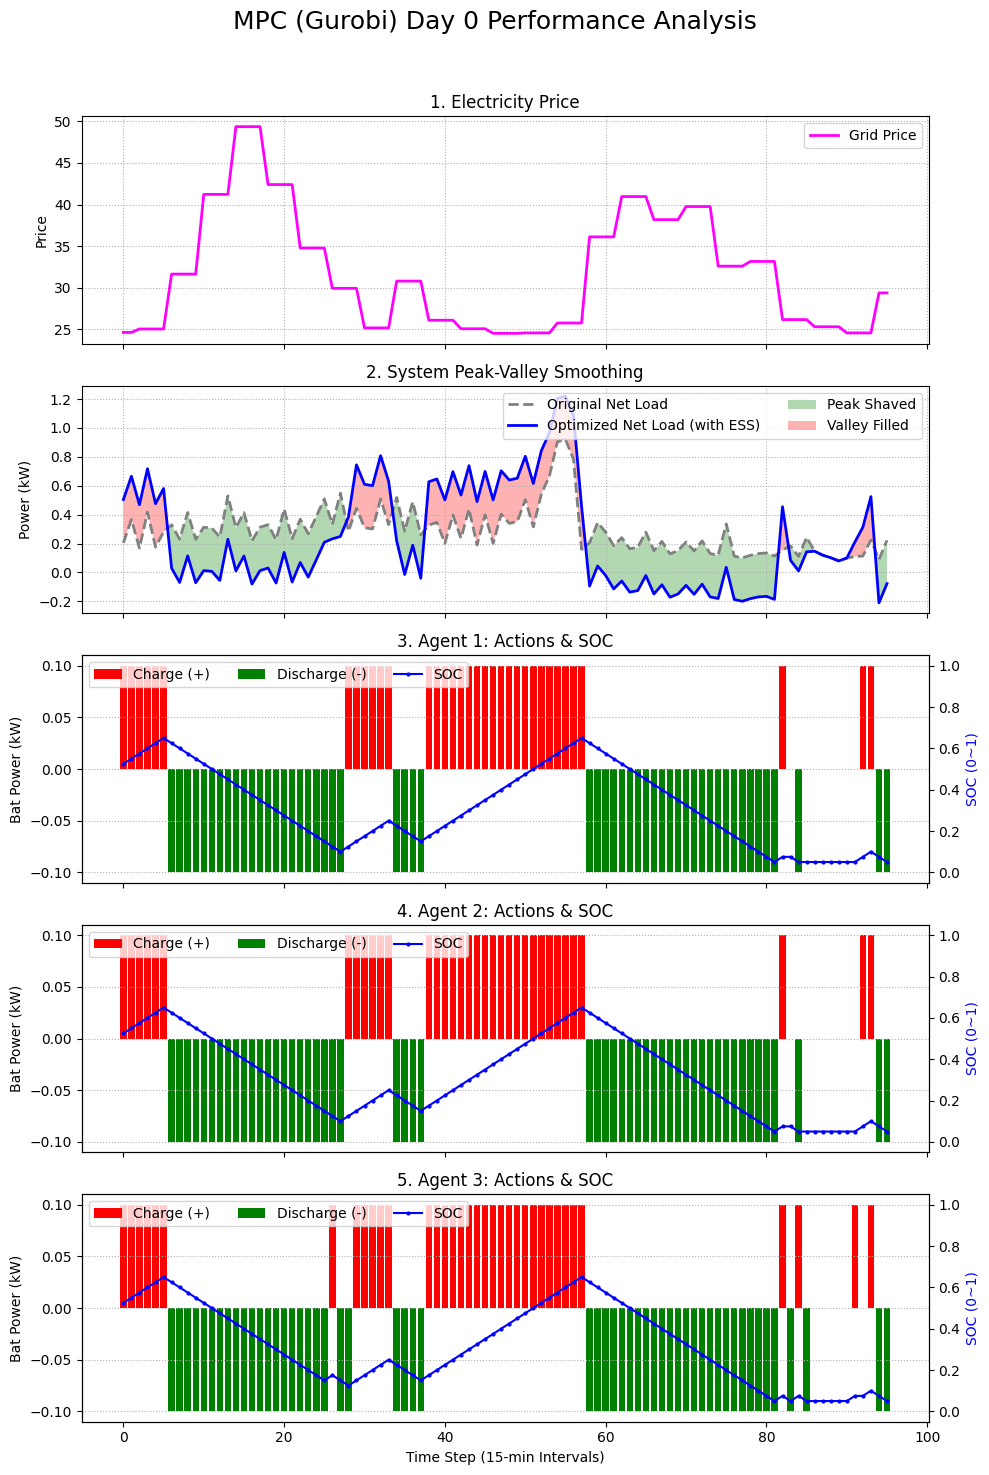

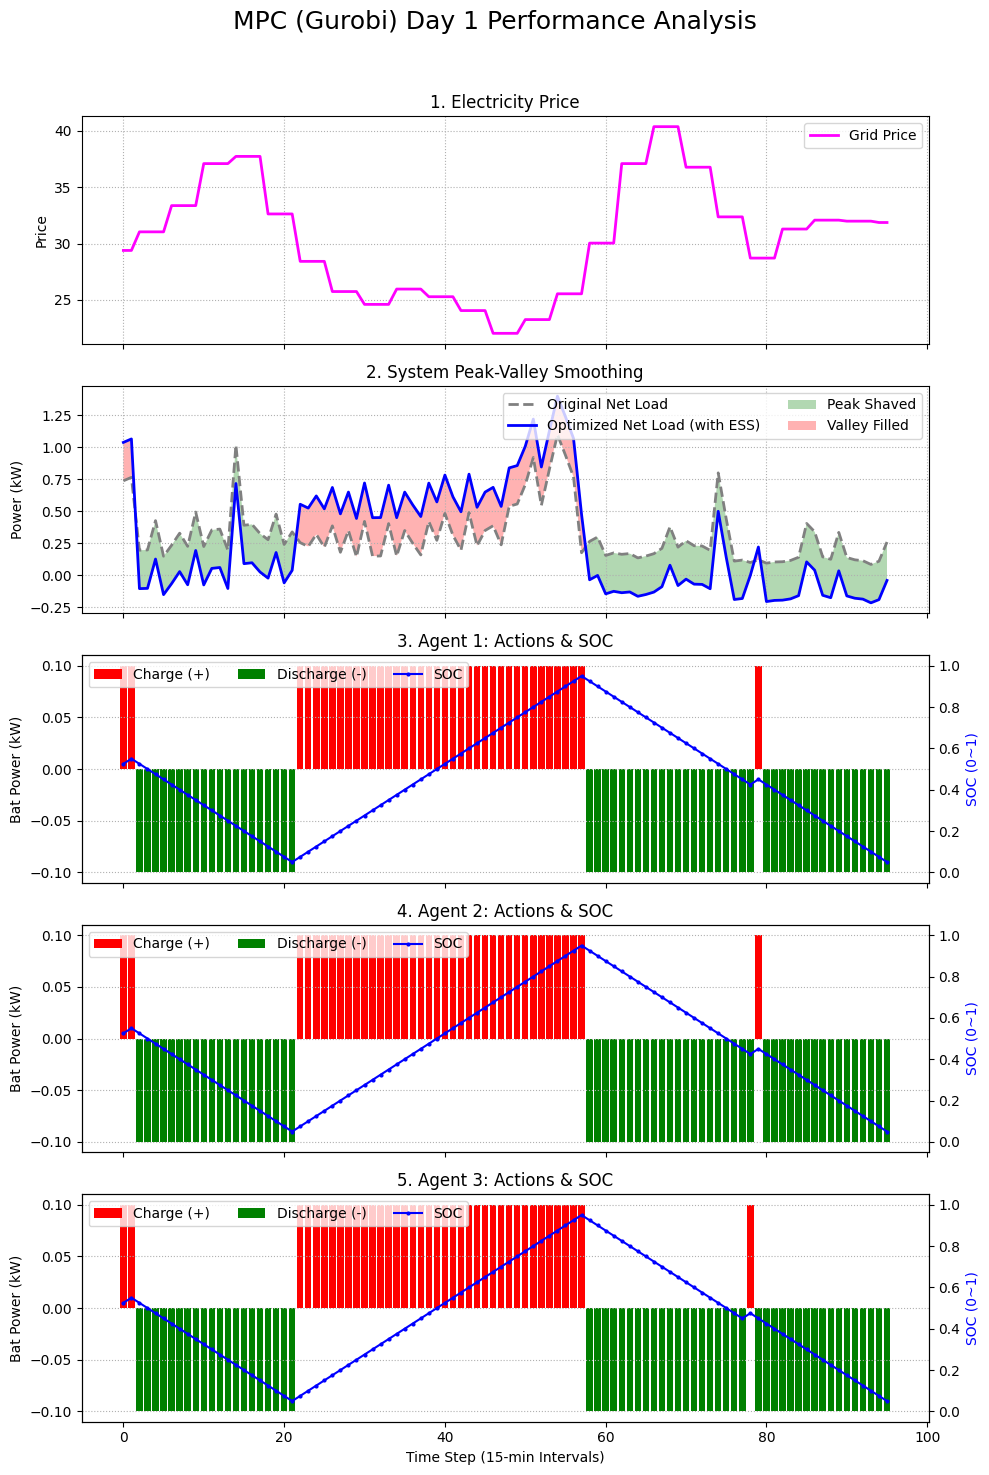

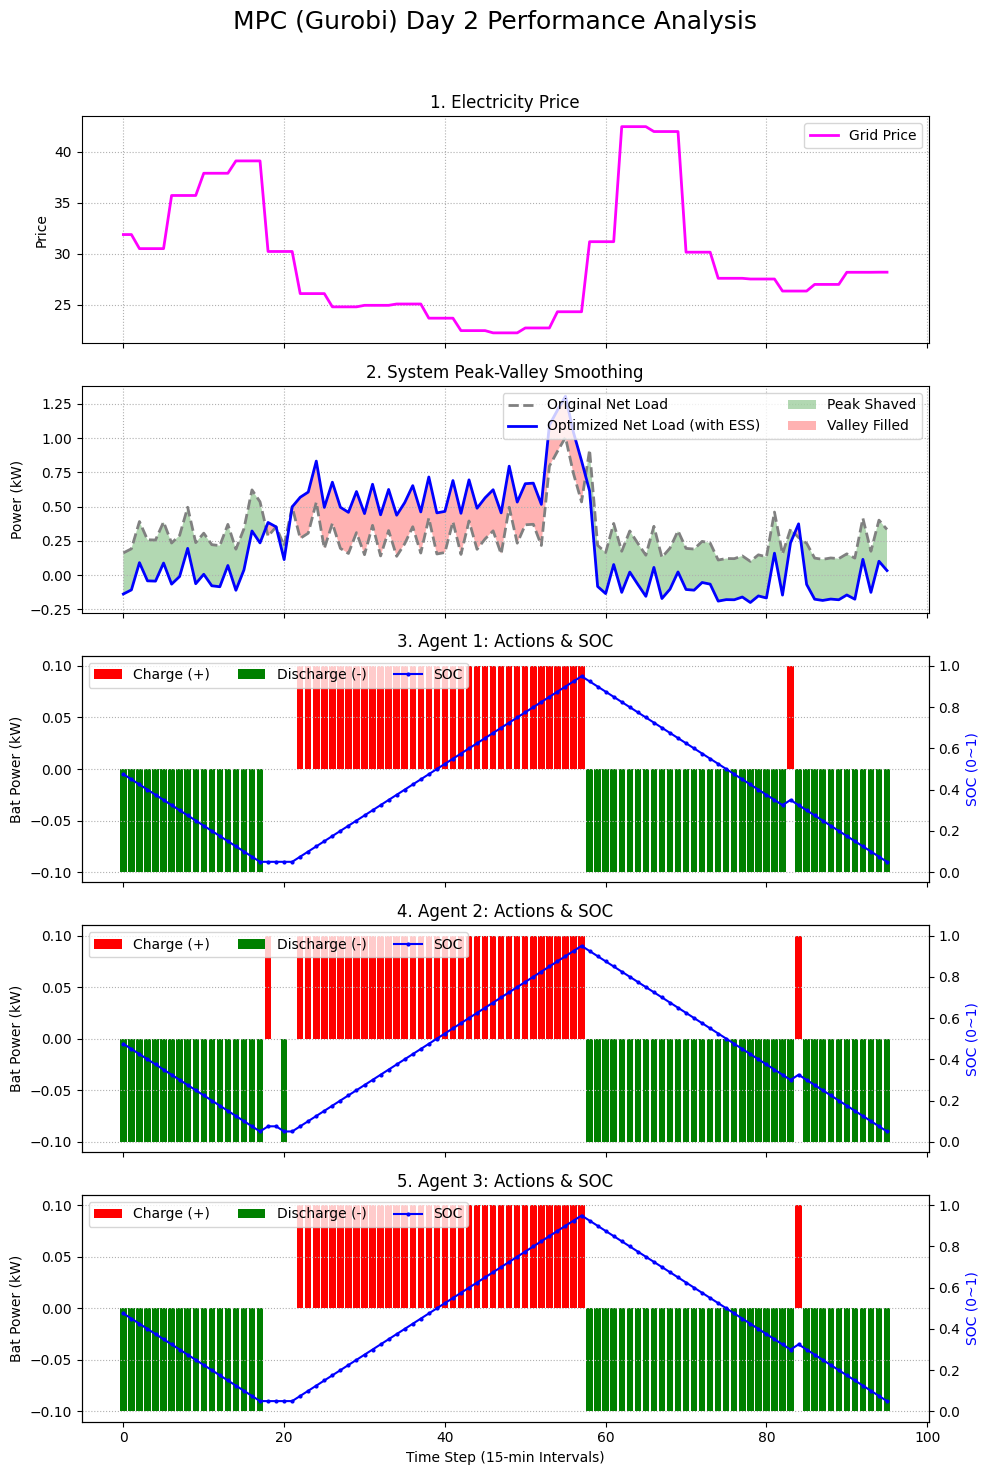

In [4]:
# ==========================================
# Cell 3: 绘制前 3 天的详细性能分析图 (MPC 版)
# ==========================================

DAYS_TO_PLOT = min(3, TEST_DAYS)
time_steps = np.arange(EPISODE_LENGTH)

for i_day in range(DAYS_TO_PLOT):
    day_data = mpc_results[i_day]
    actual_day_idx = TEST_START_DAY + i_day
    
    # 创建画布
    fig, axs = plt.subplots(2 + N_AGENTS, 1, figsize=(10, 3 * (2 + N_AGENTS)), sharex=True)
    fig.suptitle(f'MPC (Gurobi) Day {actual_day_idx} Performance Analysis', fontsize=18, y=0.98)
    
    # ---------------- 子图 1: 电价 ----------------
    ax_price = axs[0]
    ax_price.plot(time_steps, day_data['price'], color='magenta', linewidth=2, label='Grid Price')
    ax_price.set_ylabel('Price')
    ax_price.set_title('1. Electricity Price')
    ax_price.grid(True, linestyle=':')
    ax_price.legend(loc='upper right')
    
    # ---------------- 子图 2: 负荷峰谷对比 ----------------
    ax_load = axs[1]
    ax_load.plot(time_steps, day_data['orig_load'], color='grey', linestyle='--', linewidth=2, label='Original Net Load')
    ax_load.plot(time_steps, day_data['net_load'], color='blue', linewidth=2, label='Optimized Net Load (with ESS)')
    ax_load.set_ylabel('Power (kW)')
    ax_load.set_title('2. System Peak-Valley Smoothing')
    
    ax_load.fill_between(time_steps, day_data['orig_load'], day_data['net_load'], 
                         where=(np.array(day_data['net_load']) < np.array(day_data['orig_load'])), 
                         facecolor='green', alpha=0.3, interpolate=True, label='Peak Shaved')
    ax_load.fill_between(time_steps, day_data['orig_load'], day_data['net_load'], 
                         where=(np.array(day_data['net_load']) > np.array(day_data['orig_load'])), 
                         facecolor='red', alpha=0.3, interpolate=True, label='Valley Filled')
    
    ax_load.grid(True, linestyle=':')
    ax_load.legend(loc='upper right', ncol=2)
    
    # ---------------- 子图 3~5: 智能体充放电与SOC ----------------
    for ag_id in range(N_AGENTS):
        ax_agent = axs[2 + ag_id]
        
        e_bat_arr = np.array(day_data['e_bat'][ag_id])
        ax_agent.bar(time_steps, np.maximum(0, e_bat_arr), color='red', width=0.8, label='Charge (+)')
        ax_agent.bar(time_steps, np.minimum(0, e_bat_arr), color='green', width=0.8, label='Discharge (-)')
        ax_agent.set_ylabel('Bat Power (kW)', color='black')
        ax_agent.set_title(f'{3+ag_id}. Agent {ag_id+1}: Actions & SOC')
        ax_agent.grid(True, axis='y', linestyle=':')
        
        ax_soc = ax_agent.twinx()
        soc_arr = np.array(day_data['soc'][ag_id][1:]) 
        ax_soc.plot(time_steps, soc_arr, color='blue', marker='.', markersize=4, linewidth=1.5, label='SOC')
        ax_soc.set_ylabel('SOC (0~1)', color='blue')
        ax_soc.set_ylim(-0.05, 1.05)
        
        lines_1, labels_1 = ax_agent.get_legend_handles_labels()
        lines_2, labels_2 = ax_soc.get_legend_handles_labels()
        ax_agent.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', ncol=3)
        
    axs[-1].set_xlabel('Time Step (15-min Intervals)')
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()